# Day 44 — K-Means Clustering with scikit-learn

**Goal:** group 200 students into clusters using only their **CGPA** and **IQ**, with no labels given.

**What you will learn in this notebook**
1. Look at unlabeled data and guess the structure
2. Choose **K** with the **elbow method** (WCSS / inertia)
3. Train `KMeans`, read its centroids and labels, and plot the clusters
4. Check K with the **silhouette score**
5. See why **feature scaling** changes the answer
6. Predict the cluster of a new student
7. Run K-Means on **3-D** data

> 📖 Theory: read [`theory.md`](theory.md) first. Section numbers (§) below point to it.

## Step 1 — Import libraries and load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('student_clustering.csv')
print("The shape of data is", df.shape)
df.head()

The shape of data is (200, 2)


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


There is **no target column**: only two features. This is an **unsupervised** problem.
We are not predicting anything; we are looking for natural groups of students.

In [3]:
df.describe()

,cgpa,iq
count,200.000000,200.000000
mean,6.983400,101.995000
std,1.624101,12.161599
min,4.600000,83.000000
25%,5.407500,91.000000
50%,7.040000,102.000000
75%,8.585000,113.000000
max,9.300000,121.000000


Note the very different ranges: **CGPA ≈ 4.6 – 9.3** and **IQ ≈ 83 – 121**.
K-Means uses distances, so this will matter (Step 6, theory §8).

## Step 2 — Visualise the raw data

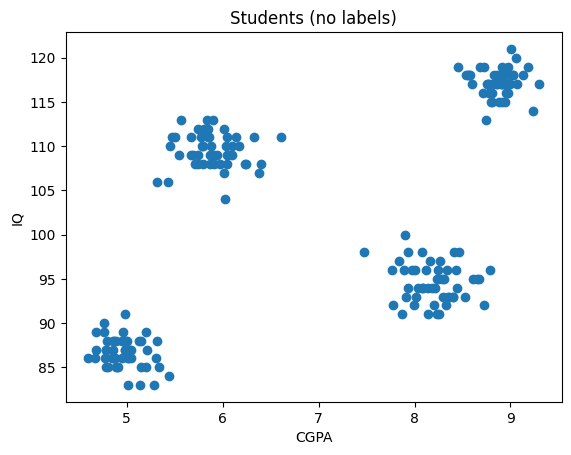

In [4]:
plt.scatter(df['cgpa'], df['iq'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Students (no labels)')
plt.show()

By eye there are **4 groups**: (low CGPA, low IQ), (low CGPA, high IQ), (high CGPA, low IQ) and
(high CGPA, high IQ). Let's see whether K-Means finds the same thing without being told.

## Step 3 — Choose K with the Elbow Method (theory §7a)

For K = 1 … 10 we train a model and record its **inertia** (WCSS):

$$\text{WCSS} = \sum_{k=1}^{K}\sum_{x_i \in C_k}\lVert x_i-\mu_k\rVert^2$$

- `n_init=10`: run 10 times from different starts and keep the best (theory §6)
- `random_state=42`: same result every time you run the notebook

In [5]:
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, n_init=10, random_state=42)
    km.fit(df)
    wcss.append(km.inertia_)

wcss

[29957.898288,
 4184.14127,
 2364.005583420083,
 681.96966,
 514.1616803171115,
 398.4039118468833,
 302.5473746759043,
 233.54082485509016,
 198.22433643678949,
 179.70292900214898]

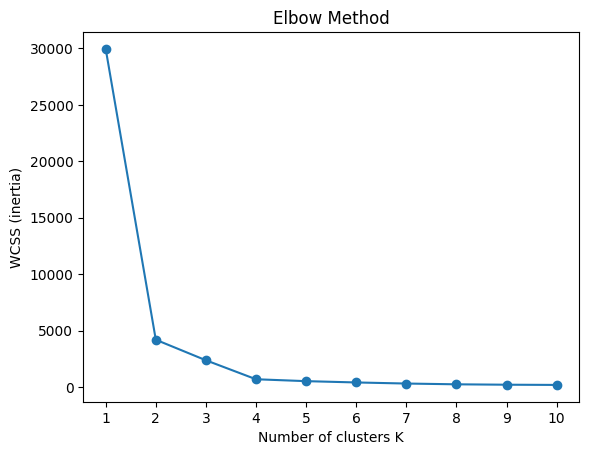

In [6]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xticks(range(1, 11))
plt.xlabel('Number of clusters K')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method')
plt.show()

**Reading the plot:** WCSS keeps falling as K grows (it always does; at K = n it would be 0).
The large drops stop after **K = 4**; from 4 → 5 the gain is small. That bend is the **elbow**, so we pick **K = 4**.

## Step 4 — Train the final model with K = 4

In [7]:
X = df.iloc[:, :].values          # numpy array, shape (200, 2)

km = KMeans(n_clusters=4, n_init=10, random_state=42)
y_means = km.fit_predict(X)        # fit + return a cluster label for every row

y_means

array([1, 0, 2, 2, 0, 0, 2, 3, 0, 2, 1, 0, 2, 1, 0, 2, 0, 2, 0, 0, 2, 1,
       2, 1, 1, 2, 1, 3, 2, 0, 3, 0, 3, 0, 2, 2, 3, 0, 1, 0, 1, 2, 2, 1,
       3, 3, 2, 0, 3, 0, 1, 1, 3, 2, 3, 0, 0, 3, 0, 3, 0, 2, 2, 3, 1, 3,
       2, 1, 0, 2, 0, 3, 2, 1, 0, 3, 0, 3, 1, 2, 2, 3, 0, 1, 3, 1, 3, 0,
       3, 0, 3, 3, 2, 1, 2, 2, 3, 2, 1, 3, 0, 1, 1, 3, 1, 1, 2, 1, 3, 3,
       2, 3, 0, 0, 2, 3, 2, 0, 3, 1, 1, 0, 2, 3, 2, 1, 2, 0, 1, 2, 2, 0,
       1, 1, 0, 3, 0, 1, 2, 2, 2, 1, 0, 1, 1, 3, 1, 3, 0, 1, 3, 1, 3, 3,
       1, 2, 0, 3, 0, 2, 1, 3, 0, 2, 3, 1, 0, 1, 1, 3, 3, 0, 3, 1, 1, 2,
       3, 0, 1, 3, 3, 0, 0, 0, 2, 1, 2, 2, 3, 0, 2, 2, 1, 1, 2, 1, 3, 0,
       0, 3], dtype=int32)

Every student now has a label 0, 1, 2 or 3. These numbers are only **names**: they carry no order,
and a different `random_state` could swap them.

What the model learned:

In [8]:
print("Centroids (cgpa, iq):\n", km.cluster_centers_)
print("Inertia (WCSS):", km.inertia_)
print("Iterations to converge:", km.n_iter_)

Centroids (cgpa, iq):
 [[  5.8948 109.52  ]
 [  4.9676  86.7   ]
 [  8.1998  94.6   ]
 [  8.8714 117.16  ]]
Inertia (WCSS): 681.96966
Iterations to converge: 3


Boolean masking selects all rows of one cluster. For example, `X[y_means == 3, 1]` means
*the IQ column (index 1) of every student in cluster 3*:

In [9]:
X[y_means == 3, 1]

array([115., 119., 117., 118., 118., 116., 116., 119., 116., 115., 115.,
       117., 118., 113., 116., 118., 117., 121., 116., 117., 117., 117.,
       114., 118., 118., 119., 118., 118., 117., 118., 117., 119., 118.,
       118., 117., 117., 117., 116., 118., 119., 117., 119., 120., 117.,
       115., 115., 117., 116., 118., 117.])

## Step 5 — Visualise the clusters and centroids

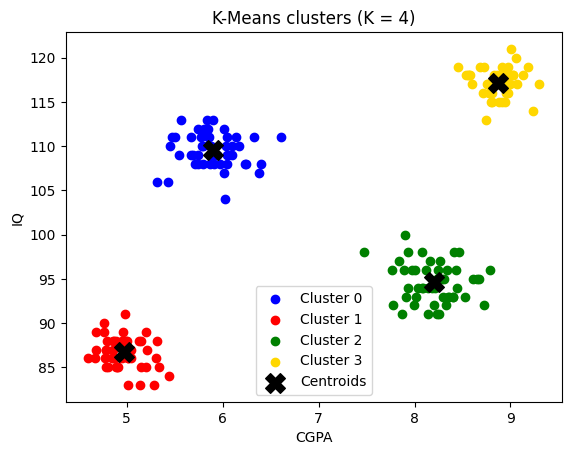

In [10]:
colors = ['blue', 'red', 'green', 'gold']

for k in range(4):
    plt.scatter(X[y_means == k, 0], X[y_means == k, 1], color=colors[k], label=f'Cluster {k}')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            color='black', marker='X', s=200, label='Centroids')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('K-Means clusters (K = 4)')
plt.legend()
plt.show()

K-Means found the same 4 groups we saw by eye. **Interpret clusters through their centroids**, for example:

In [11]:
summary = df.assign(cluster=y_means).groupby('cluster').agg(
    students=('cgpa', 'size'), avg_cgpa=('cgpa', 'mean'), avg_iq=('iq', 'mean')).round(2)
summary

,students,avg_cgpa,avg_iq
cluster,,,
0,50,5.89,109.52
1,50,4.97,86.70
2,50,8.20,94.60
3,50,8.87,117.16


Now each cluster has a meaning a teacher could act on, e.g. *high IQ but low CGPA* students may be
underperforming and could get mentoring.

## Step 6 — Check K with the Silhouette Score, and see why scaling matters (theory §7b, §8)

The silhouette score is between −1 and +1; **higher is better**. We compute it for K = 2 … 10
on the **raw** data and on **standardised** data.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rows = []
for k in range(2, 11):
    raw = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    scl = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    rows.append({'K': k,
                 'silhouette_raw': silhouette_score(X, raw.labels_),
                 'silhouette_scaled': silhouette_score(X_scaled, scl.labels_)})

sil = pd.DataFrame(rows).set_index('K').round(3)
sil

,silhouette_raw,silhouette_scaled
K,,
2,0.754,0.539
3,0.711,0.649
4,0.735,0.861
5,0.692,0.739
6,0.641,0.603
7,0.605,0.473
8,0.573,0.480
9,0.565,0.485
10,0.546,0.488


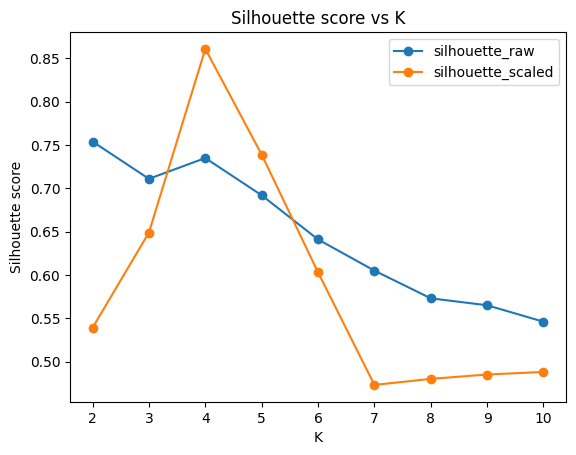

In [13]:
sil.plot(marker='o')
plt.ylabel('Silhouette score')
plt.title('Silhouette score vs K')
plt.show()

**Important result:**
- On **raw** data the silhouette score is highest at **K = 2**, which disagrees with what we see in the plot.
  IQ has the larger range, so it dominates every distance and CGPA is almost ignored.
- On **standardised** data both features count equally, and the score clearly peaks at **K = 4** (≈ 0.86).

👉 **Always scale features before K-Means** (StandardScaler from Day 7 or MinMaxScaler from Day 8).
Here the elbow on raw data happened to work because the groups are very well separated, but you
should not rely on that.

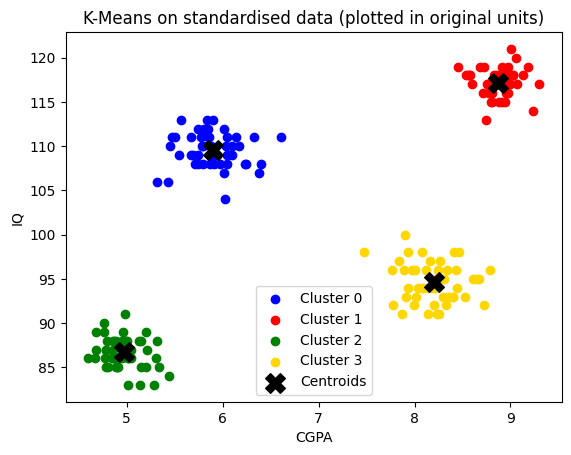

In [14]:
km_scaled = KMeans(n_clusters=4, n_init=10, random_state=42)
y_scaled = km_scaled.fit_predict(X_scaled)

for k in range(4):
    plt.scatter(X[y_scaled == k, 0], X[y_scaled == k, 1], color=colors[k], label=f'Cluster {k}')

# centroids live in scaled space -> convert back to original units to plot them
centers = scaler.inverse_transform(km_scaled.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], color='black', marker='X', s=200, label='Centroids')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('K-Means on standardised data (plotted in original units)')
plt.legend()
plt.show()

## Step 7 — Predict the cluster of new students (theory §9)

`predict` assigns each new point to its nearest **already-learned** centroid; the centroids do not move.
New data must go through the **same fitted scaler**, so use `transform`, never `fit_transform`.

In [15]:
new_students = pd.DataFrame({'cgpa': [8.9, 5.0], 'iq': [118, 87]})

new_scaled = scaler.transform(new_students.values)
new_students['cluster'] = km_scaled.predict(new_scaled)
new_students

,cgpa,iq,cluster
0,8.9,118,1
1,5.0,87,2


## Step 8 — K-Means on 3-D data

K-Means works in any number of dimensions; the distance formula just gets more terms.
We create 3-D data with **4 known centres** using `make_blobs` and check whether K-Means recovers them.

In [16]:
from sklearn.datasets import make_blobs

centroids = [(-5, -5, 5), (5, 5, -5), (3.5, -2.5, 4), (-2.5, 2.5, -4)]
cluster_std = [1, 1, 1, 1]

X3, y3 = make_blobs(n_samples=200, cluster_std=cluster_std, centers=centroids,
                    n_features=3, random_state=1)
X3[:5]

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ]])

In [17]:
import plotly.express as px

fig = px.scatter_3d(x=X3[:, 0], y=X3[:, 1], z=X3[:, 2], title='3-D data (no labels)')
fig.show()

All three features already share the same scale (`make_blobs` with equal `cluster_std`), so no scaling is needed here.

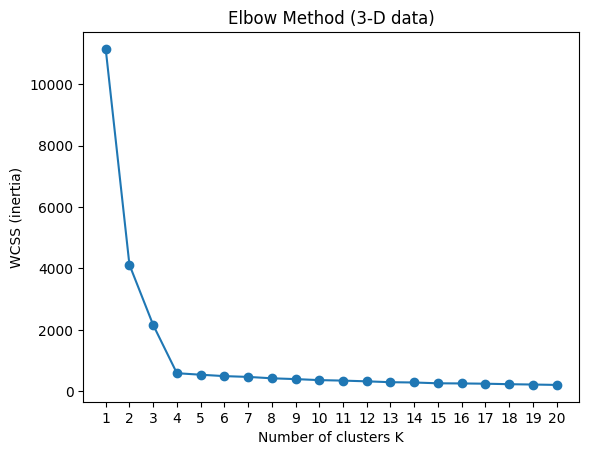

In [18]:
wcss3 = []
for i in range(1, 21):
    km3 = KMeans(n_clusters=i, n_init=10, random_state=42)
    km3.fit(X3)
    wcss3.append(km3.inertia_)

plt.plot(range(1, 21), wcss3, marker='o')
plt.xticks(range(1, 21))
plt.xlabel('Number of clusters K')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method (3-D data)')
plt.show()

The elbow is clearly at **K = 4**, the number of centres we used to generate the data.

In [19]:
km3 = KMeans(n_clusters=4, n_init=10, random_state=42)
y_pred = km3.fit_predict(X3)

df3 = pd.DataFrame(X3, columns=['col1', 'col2', 'col3'])
df3['label'] = y_pred.astype(str)      # str -> discrete colours in plotly

fig = px.scatter_3d(df3, x='col1', y='col2', z='col3', color='label', title='K-Means clusters (3-D)')
fig.show()

In [20]:
print("Learned centroids:\n", km3.cluster_centers_.round(2))
print("Silhouette score:", round(silhouette_score(X3, y_pred), 3))

Learned centroids:
 [[-4.98 -4.84  5.03]
 [ 5.01  5.02 -4.79]
 [ 3.5  -2.47  4.07]
 [-2.53  2.75 -3.97]]
Silhouette score: 0.734


The learned centroids are very close to the true centres `(-5,-5,5), (5,5,-5), (3.5,-2.5,4), (-2.5,2.5,-4)`
(possibly in a different order, because cluster numbers are arbitrary).

---
## Key takeaways
- K-Means needs only **X**; you supply **K**.
- Pick K with the **elbow** plot and confirm with the **silhouette score**.
- **Scale features first**: on raw data the silhouette score picked the wrong K.
- Use `n_init` and `random_state` for good, reproducible results.
- Interpret clusters through their **centroids**, not their label numbers.

➡️ Next: **`02-kmeans-from-scratch.ipynb`** builds the algorithm yourself, step by step.